# AI Device Health Intelligence System (ADHIS)

## Notebook: 03 - Battery Health Prediction (Regression)
**Objective:** Train a supervised ML model to predict battery health from telemetry features.  
**Dataset:** `data/raw/device_telemetry.csv`

### What this notebook covers
- Load & validate telemetry data
- Train/test split
- Train Random Forest regression model
- Evaluate RMSE and feature importance
- Save trained model artifact

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
np.random.seed(42)

DATA_PATH = Path("../data/raw/device_telemetry.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
df.head()

Shape: (5000, 7)
Missing values:
 device_id              0
battery_cycles         0
avg_temp               0
screen_on_time         0
fast_charging_count    0
cpu_usage              0
battery_health         0
dtype: int64


,device_id,battery_cycles,avg_temp,screen_on_time,fast_charging_count,cpu_usage,battery_health
0,1,152,39.943346,6.350490,61,47.558977,84.217729
1,2,485,28.242771,2.136752,118,42.799247,86.421857
2,3,910,38.351099,8.193086,263,54.995024,59.240169
3,4,320,38.384832,1.973999,238,37.287270,77.761681
4,5,156,23.632519,2.260195,254,36.969037,91.372518


In [7]:
#Features / Target
target = "battery_health"
drop_cols = ["device_id", target]

X = df.drop(columns=drop_cols)
y = df[target]

X.head(), y.head()

(   battery_cycles   avg_temp  screen_on_time  fast_charging_count  cpu_usage
 0             152  39.943346        6.350490                   61  47.558977
 1             485  28.242771        2.136752                  118  42.799247
 2             910  38.351099        8.193086                  263  54.995024
 3             320  38.384832        1.973999                  238  37.287270
 4             156  23.632519        2.260195                  254  36.969037,
 0    84.217729
 1    86.421857
 2    59.240169
 3    77.761681
 4    91.372518
 Name: battery_health, dtype: float64)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [3]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Evaluate

In [9]:
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 2.4290913058511383


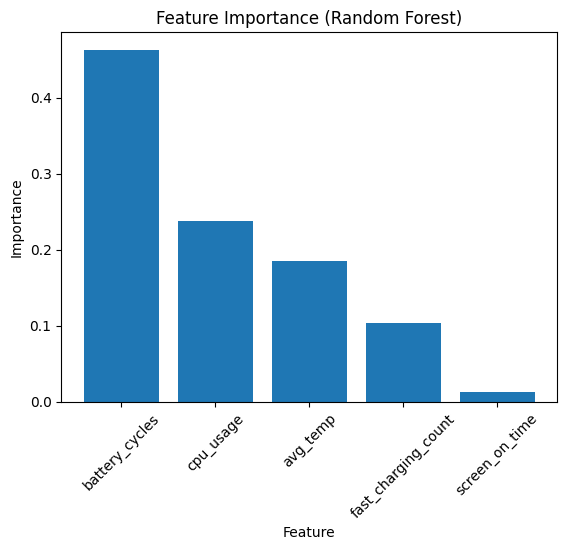

battery_cycles         0.463234
cpu_usage              0.237035
avg_temp               0.184434
fast_charging_count    0.102896
screen_on_time         0.012402
dtype: float64

In [10]:
#Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure()
plt.bar(importances.index, importances.values)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

importances

In [11]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_DIR / "battery_model.pkl")
print("Saved:", MODEL_DIR / "battery_model.pkl")

Saved: ../models/battery_model.pkl


## Summary
- Trained Random Forest model to predict battery health
- Achieved low RMSE (strong predictive performance)
- Identified most important telemetry drivers
- Saved model artifact for deployment (Streamlit + GenAI explanations)